<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# we import  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
df= pd.read_csv("bank-loan.csv")
print(df.head())

   age  ed  employ  address  income  debtinc   creddebt   othdebt  default  \
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0   
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0   
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0   
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0   
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0   

   Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12 Unnamed: 13 Unnamed: 14  \
0         NaN          NaN          NaN          NaN         NaN         NaN   
1         NaN          NaN          NaN  Credit card        2200         NaN   
2         NaN          NaN          NaN    Car  loan         450         NaN   
3         NaN          NaN          NaN  Total debts        2650         NaN   
4         NaN          NaN          NaN       income         NaN         NaN   

  Unnamed: 15 Unnamed: 16 Unnamed: 17 Unnamed: 18 

In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          850 non-null    int64  
 1   ed           850 non-null    int64  
 2   employ       850 non-null    int64  
 3   address      850 non-null    int64  
 4   income       850 non-null    int64  
 5   debtinc      850 non-null    float64
 6   creddebt     850 non-null    float64
 7   othdebt      850 non-null    float64
 8   default      700 non-null    float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  0 non-null      float64
 12  Unnamed: 12  7 non-null      object 
 13  Unnamed: 13  7 non-null      object 
 14  Unnamed: 14  1 non-null      object 
 15  Unnamed: 15  7 non-null      object 
 16  Unnamed: 16  1 non-null      object 
 17  Unnamed: 17  7 non-null      object 
 18  Unnamed: 18  1 non-null      object 
 19  Unnamed:

In [5]:
# checking for misingvalues
print(df.isnull().sum())


age              0
ed               0
employ           0
address          0
income           0
debtinc          0
creddebt         0
othdebt          0
default        150
Unnamed: 9     850
Unnamed: 10    850
Unnamed: 11    850
Unnamed: 12    843
Unnamed: 13    843
Unnamed: 14    849
Unnamed: 15    843
Unnamed: 16    849
Unnamed: 17    843
Unnamed: 18    849
Unnamed: 19    850
dtype: int64


In [6]:
# handling missing values
# Drop columns that are mostly (or entirely) empty (the 'Unnamed' columns)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

# Now, handle missing values in the 'default' column
# Since 'default' is the target variable, dropping rows with missing 'default' is often appropriate.
df.dropna(subset=['default'], inplace=True)

print(df.isnull().sum())

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64


In [7]:
print(df.describe(include='all'))

              age          ed      employ     address      income     debtinc  \
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000   
mean    34.860000    1.722857    8.388571    8.278571   45.601429   10.260571   
std      7.997342    0.928206    6.658039    6.824877   36.814226    6.827234   
min     20.000000    1.000000    0.000000    0.000000   14.000000    0.400000   
25%     29.000000    1.000000    3.000000    3.000000   24.000000    5.000000   
50%     34.000000    1.000000    7.000000    7.000000   34.000000    8.600000   
75%     40.000000    2.000000   12.000000   12.000000   55.000000   14.125000   
max     56.000000    5.000000   31.000000   34.000000  446.000000   41.300000   

         creddebt     othdebt     default  
count  700.000000  700.000000  700.000000  
mean     1.553553    3.058209    0.261429  
std      2.117197    3.287555    0.439727  
min      0.011696    0.045584    0.000000  
25%      0.369059    1.044178    0.000000  
50%   

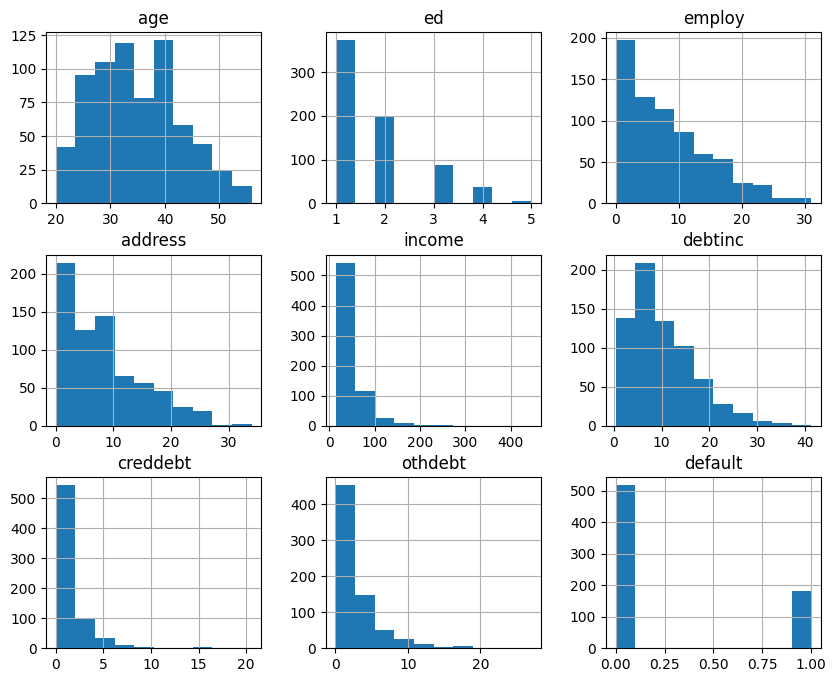

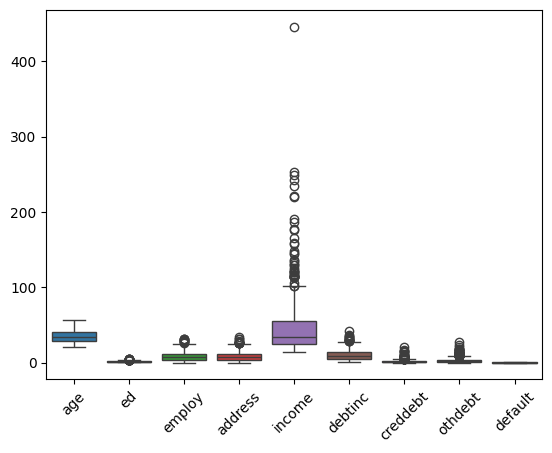

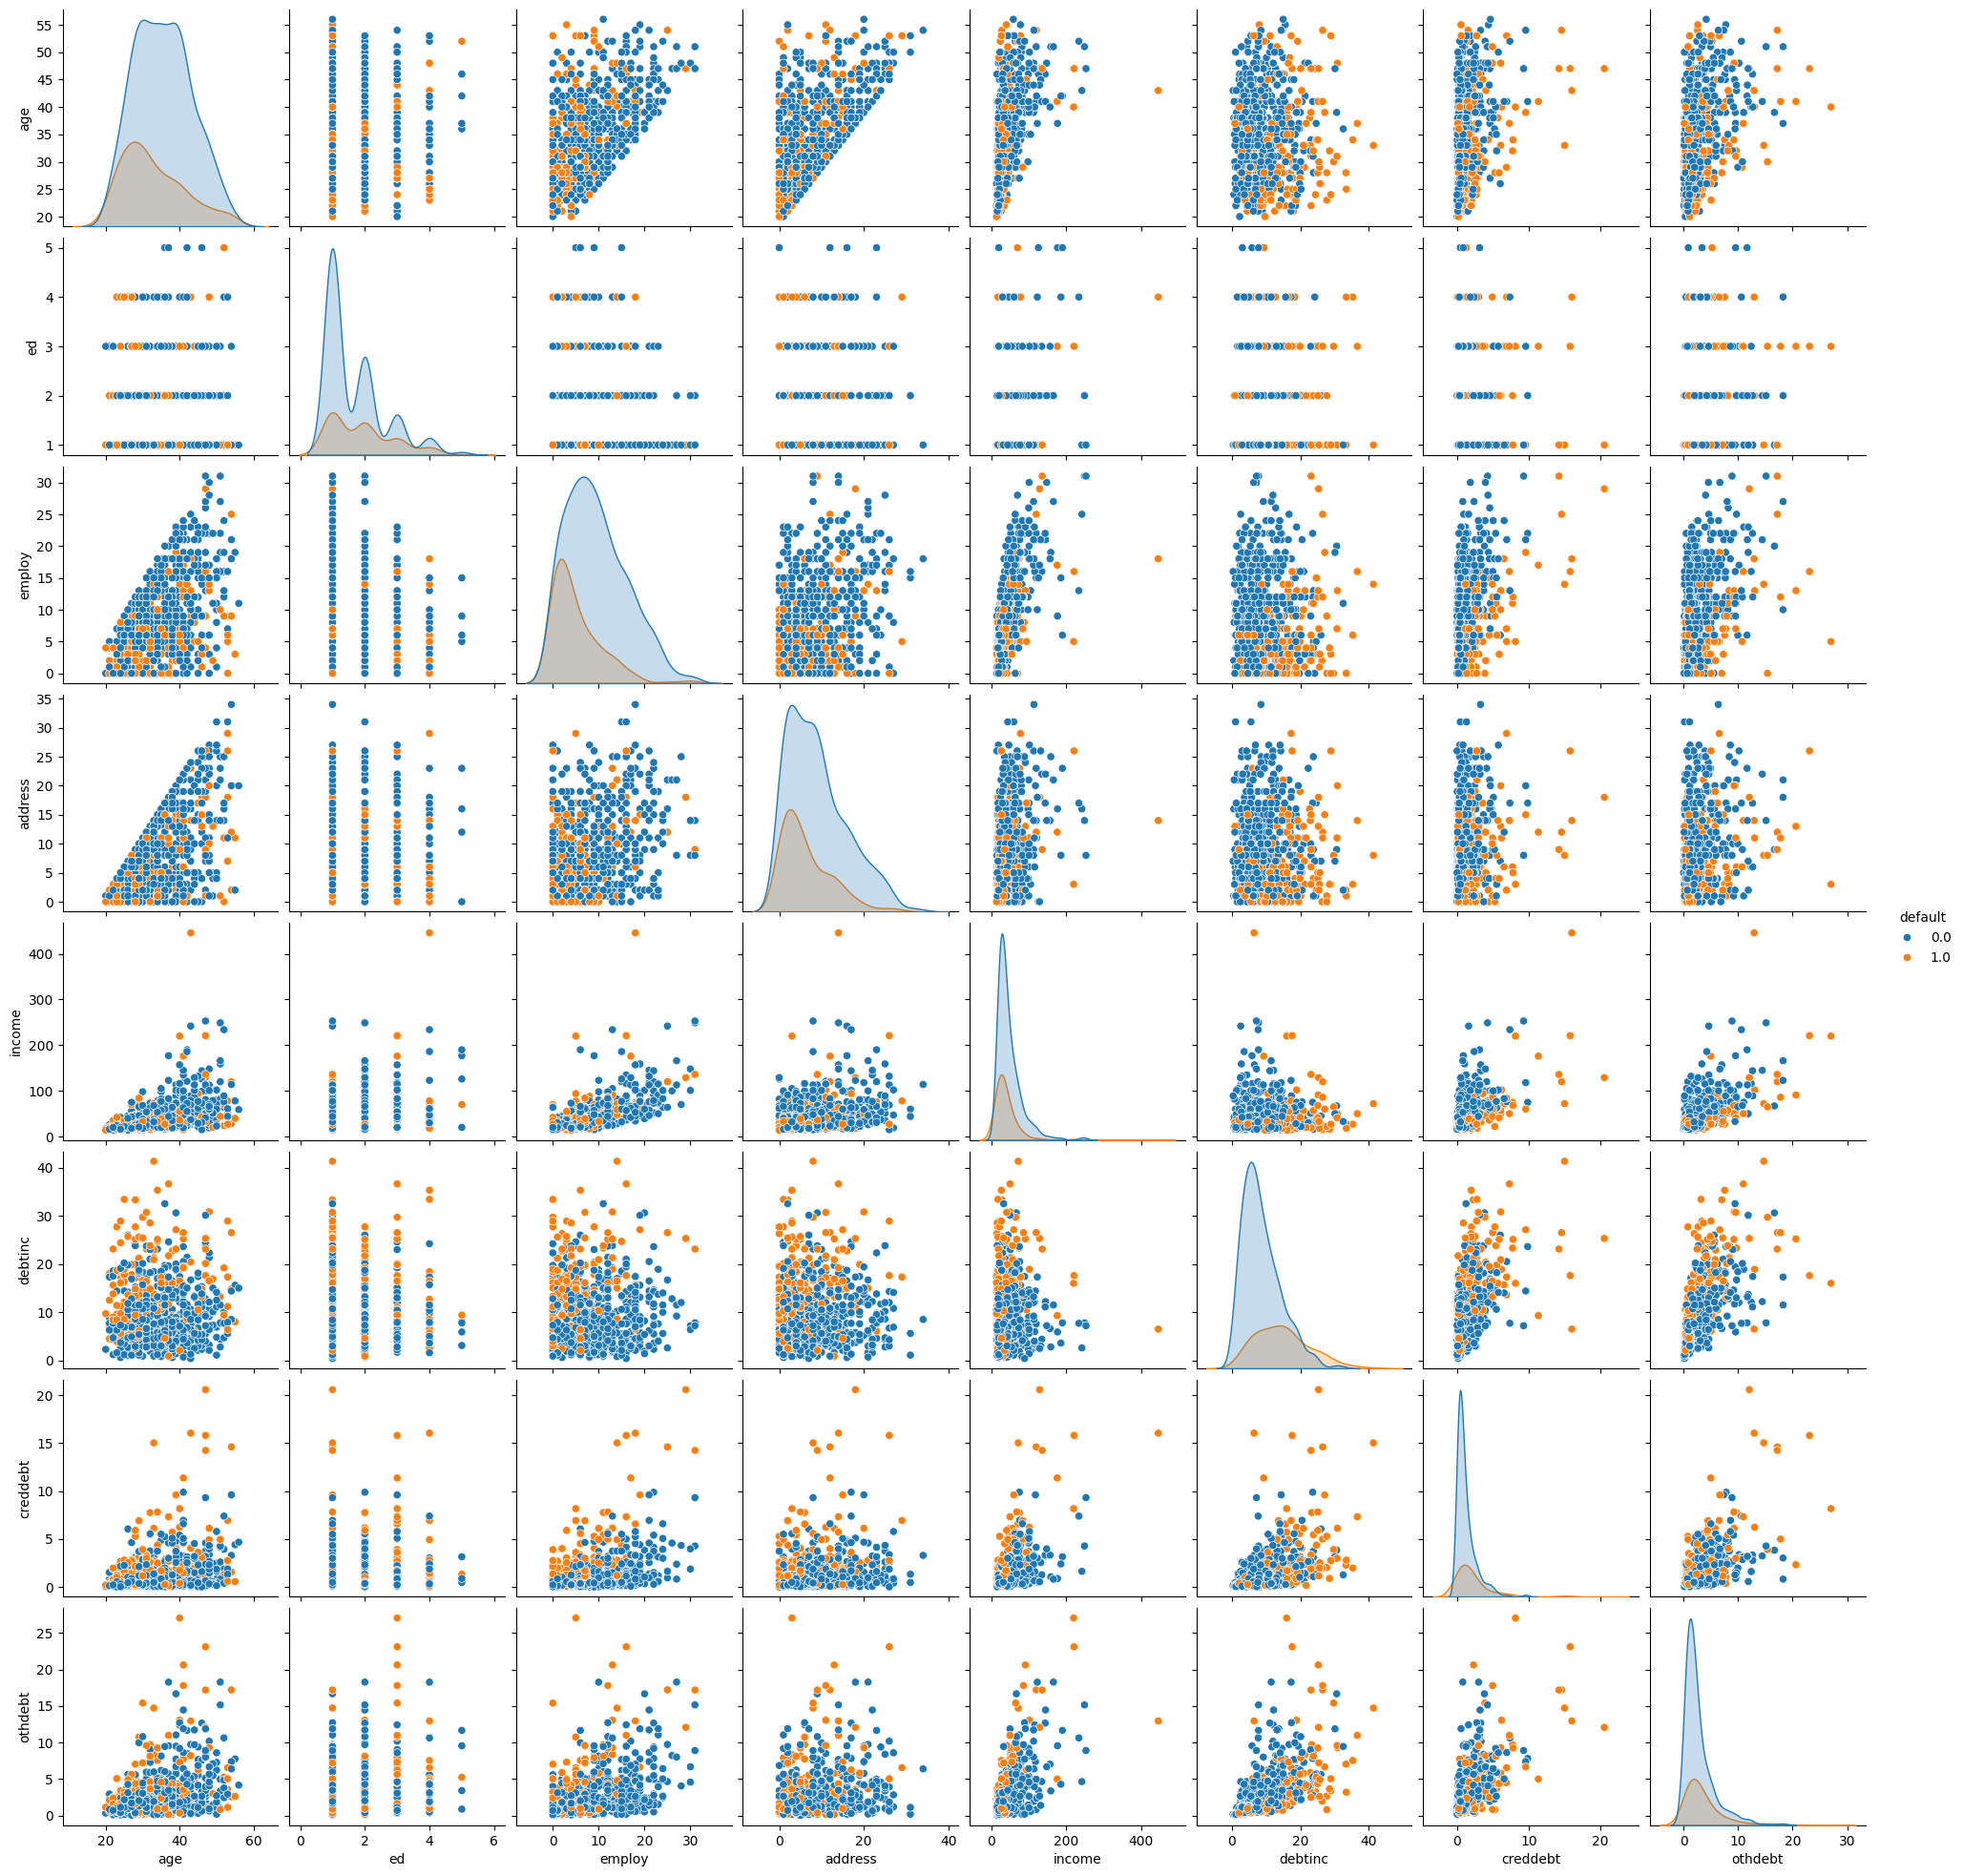

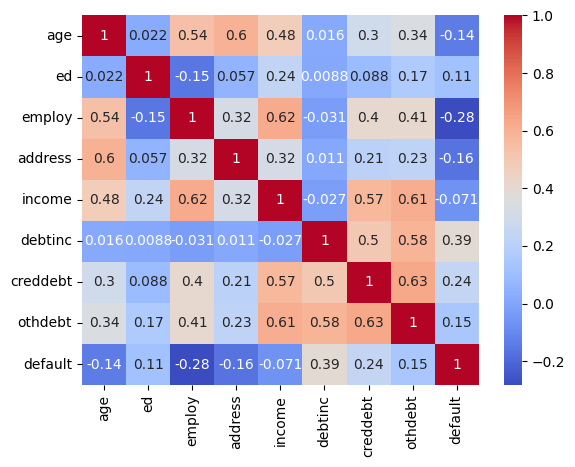

In [8]:
# data  visualization
# Distribution of features
df.hist(figsize=(10,8))
plt.show()

# Boxplots (detect outliers)
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

# Pairwise relationships
sns.pairplot(df, hue='default')
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
# normalization
num_cols = ['age', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [10]:
# feature engeneering
df['total_debt'] = df['creddebt'] + df['othdebt']
df['high_debt_burden'] = df['debtinc'] * df['income']
df['debt_income_ratio'] = df['total_debt'] / (df['income'] + 1)
print(df.head())


        age  ed    employ   address    income   debtinc  creddebt   othdebt  \
0  0.768304   3  1.294313  0.545664  3.544603 -0.140798  4.634831  0.593692   
1 -0.983529   1  0.242201 -0.334101 -0.396908  1.031818 -0.090444  0.286919   
2  0.643173   1  0.993709  0.838919  0.255480 -0.697790 -0.329670 -0.270693   
3  0.768304   1  0.993709  0.838919  2.022364 -1.078890  0.522369 -0.680910   
4 -1.358922   2 -0.960214 -1.213867 -0.478457  1.031818  0.110547 -0.000501   

   default  total_debt  high_debt_burden  debt_income_ratio  
0      1.0    5.228523         -0.499072           1.150491  
1      0.0    0.196476         -0.409537           0.325780  
2      0.0   -0.600364         -0.178271          -0.478195  
3      0.0   -0.158541         -2.181909          -0.052456  
4      1.0    0.110047         -0.493680           0.211002  


In [11]:
# Model development
X = df.drop('default', axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [13]:
# Train model
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [14]:
# Predictions
y_pred = rf.predict(X_test)

In [15]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7857142857142857
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.86       103
         1.0       0.61      0.54      0.57        37

    accuracy                           0.79       140
   macro avg       0.72      0.71      0.71       140
weighted avg       0.78      0.79      0.78       140

